# Generic Trend Model

This notebook will focus on developing a simple trend following model based originally on *Tail Protection for Long Investors: Trend Convexity at Work*

# Packages

In [105]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [106]:
from tqdm import tqdm
tqdm.pandas()

# Collecting Data

In [2]:
path   = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\FuturesPX.parquet"
df_fut = (pd.read_parquet(
    path = path, engine = "pyarrow").
    rename(columns = {"ticker": "security"}).
    assign(ticker = lambda x: x.security.str.split("1").str[0].str.strip()))

In [3]:
path         = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\TickerGuide.xlsx"
good_tickers = (pd.read_excel(
    io = path, sheet_name = "fut_guide").
    rename(columns = {"Root Contract": "tmp"}).
    assign(tmp = lambda x: x.tmp.str.strip()).
    tmp.
    drop_duplicates().
    sort_values().
    to_list())

In [4]:
df_wider_px = (df_fut.query(
    "ticker == @good_tickers").
    pivot(index = "date", columns = "ticker", values = "adj_val"))

In [80]:
df_fut_rtn = (df_wider_px.pct_change().reset_index().melt(
    id_vars = "date", value_name = "fut_rtn").
    dropna())

df_long_only = (df_fut_rtn.pivot(
    index = "date", columns = "ticker", values = "fut_rtn").
    apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    mean(axis = 1).
    to_frame(name = "Long Only"))

# Getting Benchmark Trend Data and Generating Generic Trend Signal

In [81]:
path     = r"C:\Users\Diego\Desktop\WeekyNotebooks\20260422AprilDataCollect (passed)\TrendIndices.parquet"
df_trend = (pd.read_parquet(
    path = path, engine = "pyarrow").
    assign(
        date     = lambda x: pd.to_datetime(x.date).dt.date,
        security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change()
    [["NEIXCTAT"]])

In [82]:
df_signal = (df_wider_px.diff().apply(
    lambda x: x / x.ewm(span = 10, adjust = False).std()).
    apply(lambda x: x.ewm(span = 100, adjust = False).mean()))

# Case 1: Generic Model

In [83]:
df_signal_rtn = (df_wider_px.pct_change() * np.sign(df_signal.shift()))
df_vol_rtn    = (df_signal_rtn.apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))))

In [84]:
df_gen = (df_vol_rtn.apply(
    lambda x: np.where(np.abs(x) >= 12, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "Generic TF").
    dropna())

In [85]:
df_generic_compare = (df_trend.merge(
    right = df_gen, how = "inner", on = ["date"]).
    merge(right = df_long_only, how = "inner", on = ["date"]))

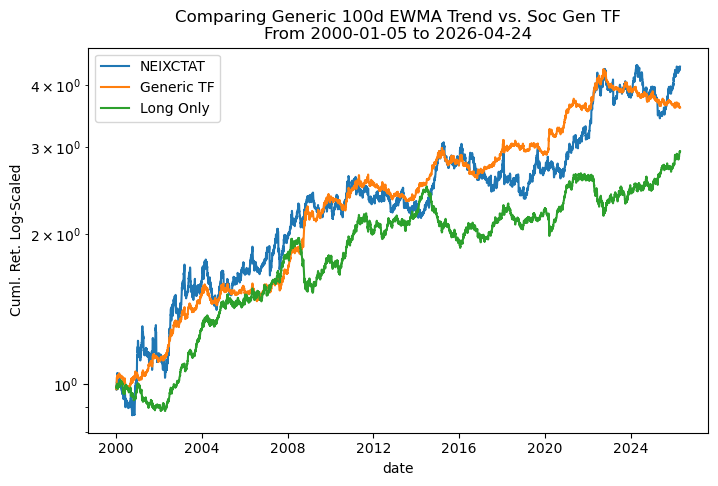

In [86]:
(df_generic_compare.
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Comparing Generic 100d EWMA Trend vs. Soc Gen TF\nFrom {} to {}".format(
            df_generic_compare.index.min(),
            df_generic_compare.index.max())))

plt.show()

In [89]:
(df_generic_compare.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe"))

,sharpe
NEIXCTAT,0.491553
Generic TF,0.748665
Long Only,0.554327


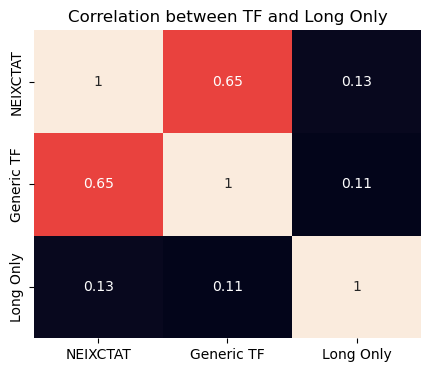

In [99]:
fig, axes = plt.subplots(figsize = (5,4))

sns.heatmap(
    ax    = axes,
    data  = df_generic_compare.corr(),
    annot = True,
    cbar  = False)

axes.set_title("Correlation between TF and Long Only")
plt.show()

# Case 2: Generic OLS Residuals

In [102]:
df_signal = (df_wider_px.diff().apply(
    lambda x: x / x.ewm(span = 10, adjust = False).std()).
    apply(lambda x: x.ewm(span = 100, adjust = False).mean()).
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "lag_signal").
    dropna())

In [103]:
df_rtn = (df_wider_px.pct_change().apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "vol_rtn").
    dropna())

In [107]:
def _get_ols(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 

    df_is = (sm.OLS(
        endog = df.vol_rtn,
        exog  = sm.add_constant(df.lag_signal)).
        fit().
        fittedvalues.
        to_frame(name = "is_pred"))

    oos_model = (RollingOLS(
        endog     = df.vol_rtn,
        exog      = sm.add_constant(df.lag_signal),
        expanding = True,
        min_nobs  = 30).
        fit())

    df_out = (oos_model.params.rename(
        columns = {"lag_signal": "beta"}).
        shift().
        merge(right = df, how = "inner", on = ["date"]).
        assign(os_pred = lambda x: (x.beta * x.lag_signal) + x.const).
        merge(right = df_is, how = "inner", on = ["date"]).
        drop(columns = ["const", "beta"]))

    return df_out

df_ols = (df_signal.merge(
    right = df_rtn, how = "inner", on = ["date", "ticker"]).
    set_index("date").
    groupby("ticker").
    progress_apply(lambda group: _get_ols(group)).
    reset_index())

100%|██████████████████████████████████████████████████████████████████████████████████| 73/73 [02:21<00:00,  1.94s/it]


In [131]:
df_ols_port = (df_ols.drop(
    columns = ["lag_signal", "vol_rtn"]).
    melt(id_vars = ["date", "ticker"], var_name = "signal_name", value_name = "signal").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn).
    pivot(index = "date", columns = ["signal_name", "ticker"], values = "signal_rtn").
    apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 10, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna().
    drop(columns = ["ticker"]).
    groupby(["date", "signal_name"]).
    agg("mean").
    reset_index().
    pivot(index = "date", columns = "signal_name", values = "value").
    rename(columns = {
        "is_pred": "IS OLS",
        "os_pred": "OS OLS"}))

In [145]:
df_ols_compare = (df_ols_port.merge(
    right = df_generic_compare, how = "inner", on = ["date"]))

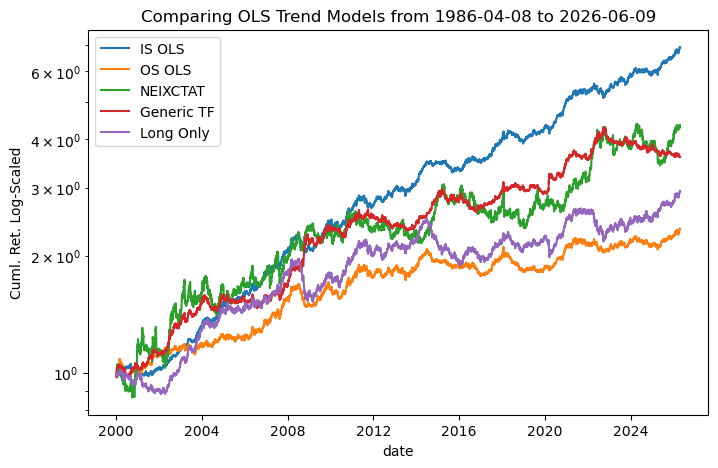

In [146]:
(df_ols_compare.apply(
    lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Comparing OLS Trend Models from {} to {}".format(
            df_ols_port.index.min(),
            df_ols_port.index.max())))

plt.show()

In [147]:
(df_ols_compare.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "Sharpe").
    T)

,IS OLS,OS OLS,NEIXCTAT,Generic TF,Long Only
Sharpe,1.302822,0.558017,0.491553,0.748665,0.554327


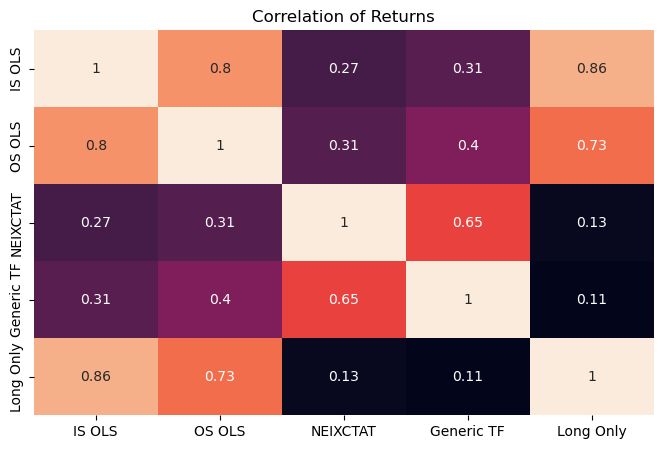

In [153]:
fig, axes = plt.subplots(figsize = (8,5))

sns.heatmap(
    ax    = axes,
    data  = df_ols_compare.corr(),
    cbar  = False,
    annot = True)

axes.set_title("Correlation of Returns")
plt.show()

In [166]:
df_combo_compare = (df_ols_compare[
    ["OS OLS", "Generic TF"]].
    mean(axis = 1).
    to_frame(name = "Combo").
    merge(right = df_ols_compare, how = "inner", on = ["date"])
    [["Combo", "NEIXCTAT", "Long Only", "Generic TF"]])

<Axes: xlabel='date'>

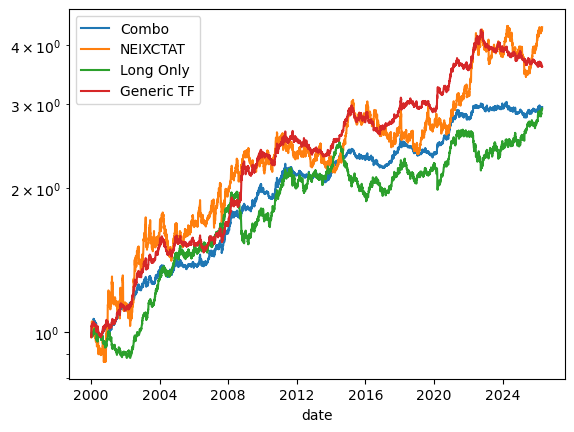

In [167]:
(df_combo_compare.apply(
    lambda x: np.cumprod(1 + x)).
    plot(logy = True))

In [169]:
df_combo_compare.agg(lambda x: x.mean() / x.std() * np.sqrt(252))

Combo         0.787456
NEIXCTAT      0.491553
Long Only     0.554327
Generic TF    0.748665
dtype: float64

# Generic Optimized Deciles

In [25]:
def _get_decile(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 

    display(df.assign(
        decile ))
    
(df_signal.set_index(
    "date").
    query("ticker == ticker.min()").
    groupby("ticker").
    apply(_get_decile))

,lag_signal
date,
2000-01-06,0.391860
2000-01-07,0.371454
2000-01-10,0.366043
2000-01-11,0.363321
2000-01-12,0.365222
...,...
2026-06-03,0.076859
2026-06-04,0.045433
2026-06-05,0.048908


,lag_signal
